  user_id   role  last_login_days  failed_attempts  mfa_enabled
1    U002   User               45                5        False
2    U003   User               90               10        False
4    U005   User              120                7        False
6    U007  Admin              200               15        False


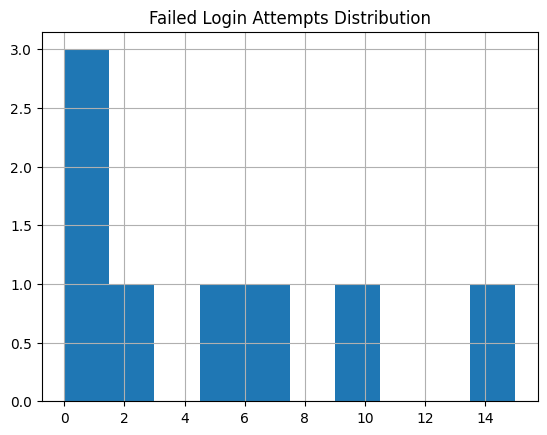

In [ ]:
#1a. User Access Logs Dataset
import pandas as pd
access_logs=pd.DataFrame({
'user_id':['U001','U002','U003','U004','U005','U006','U007','U008'],
'role':['Admin','User','User','Admin','User','User','Admin','User'],
'last_login_days':[1,45,90,2,120,5,200,3],
'failed_attempts':[0,5,10,1,7,0,15,2],
'mfa_enabled':[True,False,False,True,False,True,False,True]
})


#1b. Identify High-risk Users
high_risk_users=access_logs[
(access_logs['failed_attempts']>5)|
(access_logs['mfa_enabled']==False)
]
high_risk_users
print(high_risk_users)


#1c. Calculate Deviation (Error) Rate
total_users=len(access_logs)
non_compliant=len(access_logs[access_logs['mfa_enabled']==False])
deviation_rate=(non_compliant/total_users)*100
deviation_rate


#1d. Visualization
import matplotlib.pyplot as plt
access_logs['failed_attempts'].hist()
plt.title("Failed Login Attempts Distribution")
plt.show()

In [ ]:
#2a. System Vulnerabilities Dataset
vulnerabilities=pd.DataFrame({
'system_id':['S1','S2','S3','S4','S5'],
'critical_patches_missing':[2,0,5,1,3],
'last_patch_days':[10,2,60,30,90],
'firewall_enabled':[True,True,False,True,False]
})


#2b. Vulnerability Risk Score
vulnerabilities['risk_score']=(
vulnerabilities['critical_patches_missing']*2+
vulnerabilities['last_patch_days']/10+
(~vulnerabilities['firewall_enabled']).astype(int)*5
)
vulnerabilities.sort_values(by='risk_score',ascending=False)

In [ ]:
#3a. Incident Records Dataset
incidents=pd.DataFrame({
'incident_id':['I1','I2','I3','I4','I5'],
'severity':['High','Medium','High','Low','High'],
'response_time_hours':[72,24,96,5,120],
'resolved':[True,True,False,True,False]
})


#3b. Incident Risk Analysis
high_risk_incidents=incidents[
    (incidents['severity']=='High')&
    (incidents['response_time_hours']>48)
]
high_risk_incidents